In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import glob

plt.style.use("default")  

In [11]:
import pandas as pd
import glob
import os


folder_path = r"C:\Users\Asus\Desktop\crop"


search_pattern = os.path.join(folder_path, "*.csv")
csv_files = glob.glob(search_pattern)

print(f"Files found: {csv_files}")



Files found: ['C:\\Users\\Asus\\Desktop\\crop\\2025.csv', 'C:\\Users\\Asus\\Desktop\\crop\\2026.csv']


In [10]:
data.head()

,State,District,Market,Commodity,Variety,Grade,Arrival_Date,Min_Price,Max_Price,Modal_Price,Commodity_Code
0,Andhra Pradesh,Chittor,Chittoor,Gur (Jaggery),NO 2,FAQ,2025-01-01,3200.0,3500.0,3500.0,74
1,Tamil Nadu,The Nilgiris,Gudalur (Uzhavar Sandhai ),Garlic,Average,Local,2025-01-01,28000.0,30000.0,30000.0,25
2,Tamil Nadu,The Nilgiris,Gudalur (Uzhavar Sandhai ),Ginger (Green),Green Ginger,Local,2025-01-01,7000.0,8000.0,8000.0,103
3,Tamil Nadu,The Nilgiris,Gudalur (Uzhavar Sandhai ),Green Chilli,Green Chilly,Local,2025-01-01,4500.0,5000.0,5000.0,87
4,Tamil Nadu,The Nilgiris,Gudalur (Uzhavar Sandhai ),Mint (Pudina),Mint (Pudina),Local,2025-01-01,4500.0,5000.0,5000.0,360


In [12]:
data.columns

Index(['State', 'District', 'Market', 'Commodity', 'Variety', 'Grade',
       'Arrival_Date', 'Min_Price', 'Max_Price', 'Modal_Price',
       'Commodity_Code'],
      dtype='str')

In [13]:
data['Arrival_Date'] 
pd.to_datetime(data['Arrival_Date'], errors='coerce')
data = data.sort_values('Arrival_Date')
print(data['Arrival_Date'].min(), data['Arrival_Date'].max())

2025-01-01 2026-01-26


In [14]:
data.info()

<class 'pandas.DataFrame'>
Index: 5984442 entries, 0 to 5984441
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   State           str    
 1   District        str    
 2   Market          str    
 3   Commodity       str    
 4   Variety         str    
 5   Grade           str    
 6   Arrival_Date    str    
 7   Min_Price       float64
 8   Max_Price       float64
 9   Modal_Price     float64
 10  Commodity_Code  int64  
dtypes: float64(3), int64(1), str(7)
memory usage: 547.9 MB


In [15]:
data.isnull().sum()

State             0
District          0
Market            0
Commodity         0
Variety           0
Grade             0
Arrival_Date      0
Min_Price         0
Max_Price         0
Modal_Price       0
Commodity_Code    0
dtype: int64

In [16]:
data['Min_Price'].describe()

count    5.984442e+06
mean     4.018470e+03
std      6.081017e+03
min      0.000000e+00
25%      1.850000e+03
50%      3.000000e+03
75%      5.000000e+03
max      4.000000e+06
Name: Min_Price, dtype: float64

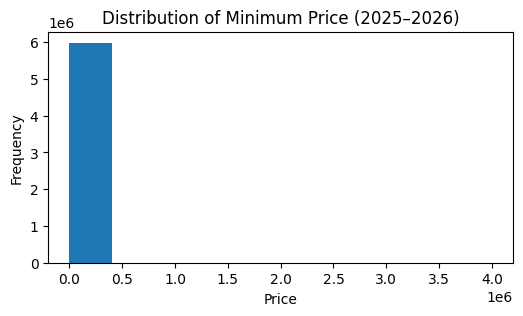

In [18]:
plt.figure(figsize=(6,3))
plt.hist(data['Min_Price'])
plt.title("Distribution of Minimum Price (2025–2026)")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

In [19]:
data['Min_Price'].dtype

dtype('float64')

In [20]:
print(data['Min_Price'].min())
print(data['Min_Price'].max())
print(data['Min_Price'].mean())
print(data['Min_Price'].unique()[:20])  # first 20 unique values


print(data['Min_Price'].value_counts().head(10))

0.0
4000000.0
4018.4704242039006
[3200.    930.    900.   1600.    800.   4000.   7800.   7500.   2400.
  933.38 3500.   2200.    600.   2000.   1800.   1467.4  2100.   1000.
 3600.   3800.  ]
Min_Price
3000.0    347514
2000.0    327418
4000.0    312564
2500.0    292110
5000.0    236850
1000.0    207377
3500.0    205783
1500.0    191883
6000.0    177700
4500.0    132427
Name: count, dtype: int64


In [21]:
top_crops = data['Commodity'].value_counts().head(10)
print("Top 10 crops:\n", top_crops)

Top 10 crops:
 Commodity
Onion                     226844
Tomato                    216087
Potato                    209354
Wheat                     193384
Brinjal                   190408
Banana                    181653
Green Chilli              180539
Bhindi (Ladies Finger)    151879
Bottle gourd              140885
Cabbage                   138396
Name: count, dtype: int64


In [22]:
df=data.copy()

In [23]:
# Strip spaces and convert to datetime safely
df['Arrival_Date'] = pd.to_datetime(df['Arrival_Date'].astype(str).str.strip(), errors='coerce')

# Check for invalid dates
invalid_dates = df['Arrival_Date'].isna().sum()
print("Number of invalid dates:", invalid_dates)

Number of invalid dates: 0


In [24]:
df = df[df['Arrival_Date'].dt.year.isin([2025, 2026])]
print("Shape after filtering:", df.shape)

Shape after filtering: (5984442, 11)


In [25]:
# Ensure numeric
df['Min_Price'] = pd.to_numeric(df['Min_Price'], errors='coerce')
print(df['Min_Price'].describe())

count    5.984442e+06
mean     4.018470e+03
std      6.081017e+03
min      0.000000e+00
25%      1.850000e+03
50%      3.000000e+03
75%      5.000000e+03
max      4.000000e+06
Name: Min_Price, dtype: float64


In [26]:
print(df.isnull().values.any())

False


In [27]:
df['Year']=df['Arrival_Date'].dt.year
print(df[['Arrival_Date','Year']].head())

      Arrival_Date  Year
0       2025-01-01  2025
10231   2025-01-01  2025
10232   2025-01-01  2025
10233   2025-01-01  2025
10234   2025-01-01  2025


In [28]:
yearly_avg = df.groupby('Year')['Min_Price'].mean()
print(yearly_avg)

Year
2025    4013.966996
2026    4189.262812
Name: Min_Price, dtype: float64


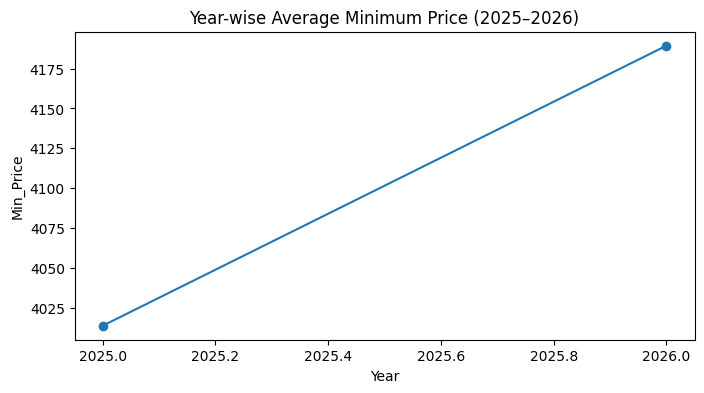

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.plot(yearly_avg.index, yearly_avg.values, marker='o')
plt.title("Year-wise Average Minimum Price (2025–2026)")
plt.xlabel("Year")
plt.ylabel("Min_Price")
plt.show()

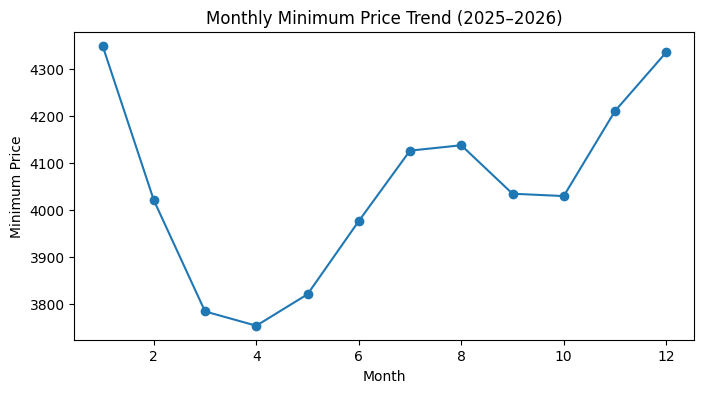

In [30]:
df['month'] = df['Arrival_Date'].dt.month
monthly_avg = df.groupby('month')['Min_Price'].mean()

plt.figure(figsize=(8,4))
plt.plot(monthly_avg.index, monthly_avg.values, marker='o')
plt.title("Monthly Minimum Price Trend (2025–2026)")
plt.xlabel("Month")
plt.ylabel("Minimum Price")
plt.show()

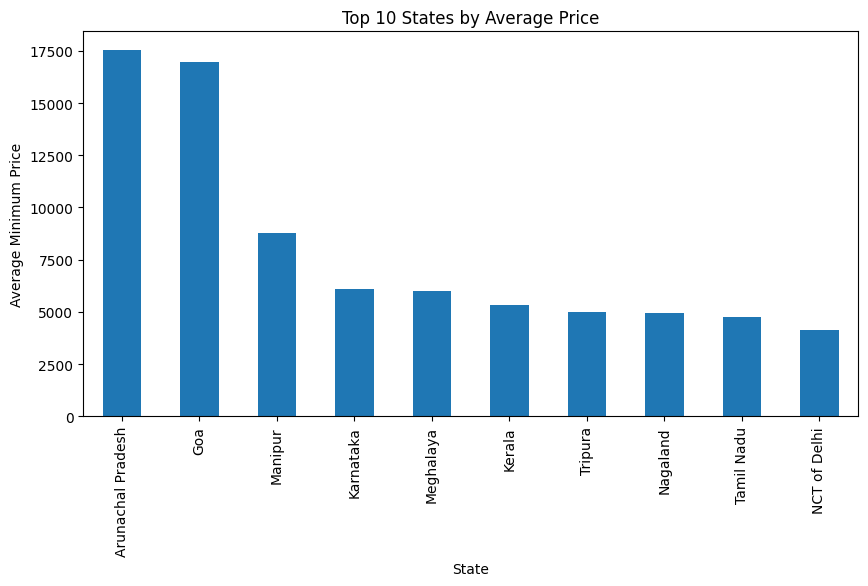

In [31]:
state_avg = df.groupby('State')['Min_Price'].mean().sort_values(ascending=False)
state_avg.head(10).plot(kind='bar', figsize=(10,5), title="Top 10 States by Average Price")
plt.xlabel("State")
plt.ylabel("Average Minimum Price")
plt.show()

In [32]:
df.to_csv("crop_25_26_combined.csv",index=False)